# FWC groups time series for OHC and MLD using KPP criteria

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:46307")
client

<Client: 'tcp://127.0.0.1:46307' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [22]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

# open KPP
kpp_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/KPPdiffS_AVG_DAILY.ZARR/', s3_options).KPPdiffS

# open density zarr store - [kg m-3]
rho_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/RHOAnoma_AVG_DAILY.ZARR/', s3_options).RHOAnoma + 1027.5

In [7]:
# carve out beaufort region
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
theta_beaufort = theta_da.isel(i=slice(450,750),j=slice(110,390))
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))
kpp_beaufort = kpp_da.isel(i=slice(450,750),j=slice(110,390))
rho_beaufort = rho_da.isel(i=slice(450,750),j=slice(110,390))

grid_beaufort = HH_grid.isel(i=slice(450,750),j=slice(110,390),k=slice(0,26)) # upper 150 m

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

## 1. Select days after sea ice minimum each year and mask SIC>15%

In [30]:
ice_beaufort = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))
beaufort_area = HH_grid.isel(i=slice(450,750),j=slice(110,390)).rAc

In [31]:
# calculating minimum based on extent (count grid cells where ice concentration >= 15% and sum their areas)

# salculate sea ice extent: sum the area of grid cells where SIC >= 15%
ice_extent = ((ice_beaufort >= 15) * beaufort_area).sum(dim=['i', 'j'])
ice_extent = ice_extent.where(ice_extent != 0)

# group by year
grouped = ice_extent.groupby("time.year")

# find the day of the minimum extent for each year
min_ice_dates = []
for year, data in grouped:
    sic_min_yr = data['time']
    min_day_tmp = sic_min_yr[data.argmin().values].values  # Get the time corresponding to min extent
    min_ice_dates.append(min_day_tmp)
    print(f"{year}: Minimum extent on {min_day_tmp}")

2014: Minimum extent on 2014-09-23T12:00:00.000000000
2015: Minimum extent on 2015-09-16T12:00:00.000000000
2016: Minimum extent on 2016-09-01T12:00:00.000000000
2017: Minimum extent on 2017-10-07T12:00:00.000000000
2018: Minimum extent on 2018-09-21T12:00:00.000000000
2019: Minimum extent on 2019-09-24T12:00:00.000000000
2020: Minimum extent on 2020-09-06T12:00:00.000000000


In [32]:
# generate daily timestamps from each min date to Dec 31 of that year
date_arrays = [np.arange(np.datetime64(date), np.datetime64(f"{str(date)[:4]}-12-31") + np.timedelta64(1, 'D'), np.timedelta64(1, 'D'))
               for date in min_ice_dates]

# concatenate into one array
full_date_array = np.concatenate(date_arrays)

In [33]:
theta_beaufort.Z.values[0:18]

array([ -0.5  ,  -1.57 ,  -2.79 ,  -4.185,  -5.78 ,  -7.595,  -9.66 ,
       -12.01 , -14.68 , -17.705, -21.125, -24.99 , -29.345, -34.24 ,
       -39.725, -45.855, -52.69 , -60.28 ], dtype=float32)

In [34]:
# select days after sea ice minimum for theta and salinity

# select all timesteps after sea ice minimum each year
sic_yrs = ice_beaufort.sel(time=full_date_array)
temp_yrs = theta_beaufort.sel(time=full_date_array).isel(k=slice(0,26)) # upper 150 m
salt_yrs = salt_beaufort.sel(time=full_date_array).isel(k=slice(0,26)) 
rho_yrs = rho_beaufort.sel(time=full_date_array).isel(k=slice(0,26)) 
# kpp_yrs = kpp_beaufort.sel(time=full_date_array).isel(k=slice(0,26)) 
kpp_yrs = kpp_beaufort.sel(time=full_date_array)

In [35]:
# look at depth of grid cell center and bottom of grid cell
# print(salt_yrs.Z.values)
# print(HH_grid.isel(k_u=slice(0,7)).Zu.values)

In [36]:
# list to store yearly masks
mask_list = []

for date in min_ice_dates:
    year = str(date.astype('datetime64[Y]'))  # Extract year as a string
    
    # select all days from the minimum ice date to Dec 31
    yearly_data = sic_yrs.sel(time=slice(str(date), f"{year}-12-31"))

    # get sea ice concentration on the minimum ice date
    sic_min_day = sic_yrs.sel(time=date)

    # create a mask for grid cells where sic >= 15% on the minimum ice date
    mask = sic_min_day >= 15  # 2D (i, j)

    # expand mask along time dimension to match yearly_data
    mask_expanded = mask.expand_dims(dim={"time": yearly_data.time}, axis=0)

    # store in list
    mask_list.append(mask_expanded)

# combine all yearly masks
sic_yrs_mask = xr.concat(mask_list, dim="time").combine_first(sic_yrs * 0)  # Align time with sic_yrs

In [37]:
# apply mask to temperature, salinity, and density ds
land_sic_mask_yr = (~sic_yrs_mask.astype(bool)) & (HH_grid.isel(i=slice(450,750),j=slice(110,390),k=0).mask_basin)

sic_yrs_masked = sic_yrs.where(land_sic_mask_yr)
salt_yrs_masked = salt_yrs.where(land_sic_mask_yr)
rho_yrs_masked = rho_yrs.where(land_sic_mask_yr)
kpp_yrs_masked = kpp_yrs.where(land_sic_mask_yr)

## 2. Open FWC

In [38]:
# open FWC zarr
fwc_yrs_masked = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/FWC/FWC_masked_Beaufort.ZARR')

## 3a. Group FWC and calculate mean OHC and MLD for time series

In [39]:
def calculate_cp_from_profile(salinity, temperature, depth, lon=-137, lat=70):
    """
    Calculate specific heat capacity (cp) of seawater from depth, temperature, and salinity.
    
    Parameters:
    - salinity (array): salinity (PSU)
    - temperature (array): temperature (°C)
    - depth (array): depth values (m, negative downward)
    - lon (float): longitude for SA calculation
    - lat (float): latitude for pressure calculation
    
    Args:
    - cp (array): Specific heat capacity (J/kg/deg K) for each depth level
    """
    # Convert depth (m) to pressure (dbar)
    pressure = gsw.p_from_z(depth, lat)  # Negative depth because z is negative downward
    
    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(salinity, pressure, lon, lat)
    
    # Compute specific heat capacity (cp) in J/(kg K)
    cp = gsw.cp_t_exact(SA, temperature, pressure)
    
    return cp

In [ ]:
def calculate_ohc(temp, salinity, density, layer_thickness, threshold_idx):
    """
    Calculate the Ocean Heat Content (OHC) relative to the freezing temperature in surface mixed layer for a time series of profiles.

    Args:
    - temp (xr.DataArray): 2D array of temperature (°C) with dimensions ['time', 'k'].
    - salinity (xr.DataArray): 2D array of salinity (PSU) with dimensions ['time', 'k'].
    - density (xr.DataArray): 2D array of seawater density (kg/m3) with dimensions ['time', 'k'].
    - layer_thickness (xr.DataArray): 1D array representing the thickness of each vertical layer (m).
    - threshold_idx (xr.DataArray): 1D array containing the maximum depth index for the MLD of each profile along the time series.

    Returns:
    - ohc (xr.DataArray): 3D array representing ocean heat content relative to the freezing temperature in the surface mixed layer for each profile (J/m2).
    """
    
    # specific heat capacity of seawater
    cp = calculate_cp_from_profile(salinity, temp, temp.Z, lon=temp.XC, lat=temp.YC)

    # # Given array of indices
    # indices = threshold_idx.compute()

    # Create mask for surface mixed layer
    mask = temp.k <= threshold_idx
    
    # Compute ocean heat content relative to freezing temperature per unit area
    temp_freezing = -1.8

    # Compute the weighted temperature anomaly and then OHC for the surface mixed layer
    weighted_temp_anomaly = (temp - temp_freezing) * layer_thickness
    weighted_temp_anomaly_layer = weighted_temp_anomaly.where(mask) # apply mask for specific depth layer
    ohc = (density * cp * weighted_temp_anomaly_layer).sum(dim='k')  # J/m^2

    # units check: (kg/m3)(J/(kg degC))(degC * m) = J/m2
    
    return ohc

In [43]:
def compute_mld_near_zero_after_peak(kpp_yrs, Z, threshold=1e-6):
    """
    Compute index and depth where the KPP profile first returns to near-zero
    AFTER the maximum value — but return the shallowest such point (closest to surface).
    
    Parameters:
        kpp_yrs (xr.DataArray): 4D input (time, i, j, k)
        Z (xr.DataArray): 1D depth levels along 'k'
        threshold (float): Threshold to define near-zero (default = 1e-6)
        
    Returns:
        out_idx (xr.DataArray): Index where profile drops below threshold after max (closest to surface)
        mld (xr.DataArray): Corresponding depth
    """

    def profile_logic(profile, z_vals):
        if not np.any(np.isfinite(profile)):
            return np.nan, np.nan

        max_idx = np.nanargmax(profile)
        if not np.isfinite(profile[max_idx]):
            return np.nan, np.nan

        # Get all indices after the peak (excluding peak) where profile < threshold
        below_threshold_idxs = np.where(profile < threshold)[0]

        # Filter to only those after the peak
        after_peak = below_threshold_idxs[below_threshold_idxs != max_idx]
        if after_peak.size == 0:
            return np.nan, np.nan

        # Choose the shallowest (smallest k) index among those
        shallowest_idx = after_peak.min()
        return float(shallowest_idx), float(z_vals[shallowest_idx])

    uses_dask = hasattr(kpp_yrs.data, 'chunks')

    out_idx, mld = xr.apply_ufunc(
        profile_logic,
        kpp_yrs,
        Z,
        input_core_dims=[['k'], ['k']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized' if uses_dask else 'forbidden',
        output_dtypes=[float, float],
        dask_gufunc_kwargs={'allow_rechunk': True}
    )

    return out_idx, mld

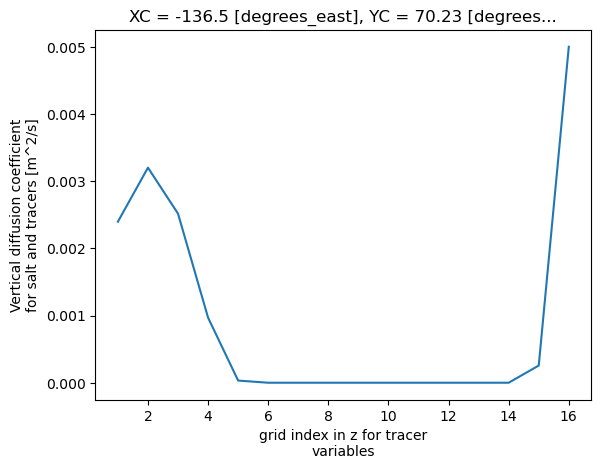

In [44]:
kpp_yrs.isel(k=slice(1,None)).isel(time=100).sel(i=566,j=171).plot();

In [45]:
out_idx, mld = compute_mld_near_zero_after_peak(kpp_yrs.isel(k=slice(1,None)), kpp_yrs.Z.isel(k=slice(1,None)), threshold = 1e-6)

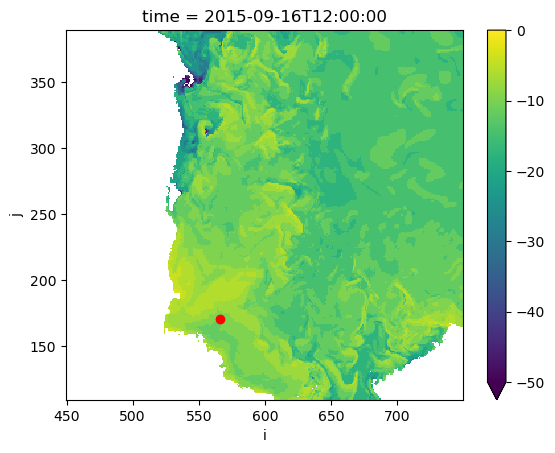

In [152]:
mld.isel(time=100).plot(vmin=-50,vmax=0);
# plt.xlim(540,570)
# plt.ylim(150,180)
plt.scatter(566,171,color='r');

In [154]:
out_idx.isel(time=100).sel(i=566,j=171).values

array(5.)

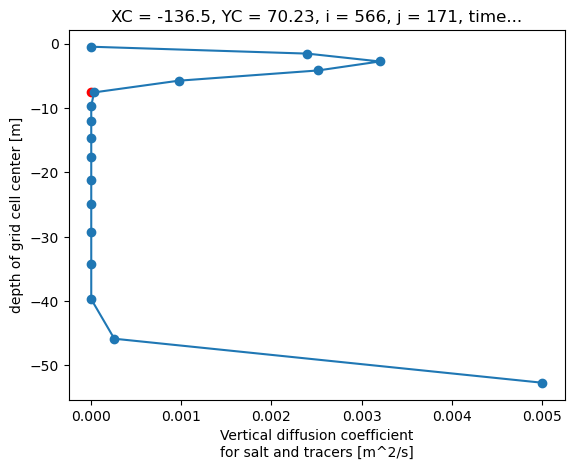

In [157]:
kpp_yrs.isel(time=100).sel(i=566,j=171).plot(y='Z',marker='o');
plt.scatter(0,kpp_yrs.isel(k=5).Z.values,color='r');

In [158]:
mld_idx_da = out_idx.load()

In [159]:
# calculate OHC
start = time.time()
ohc_mld = calculate_ohc(temp_yrs, salt_yrs, rho_yrs, grid_beaufort.drF, mld_idx_da)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

Time taken: 28.0 seconds


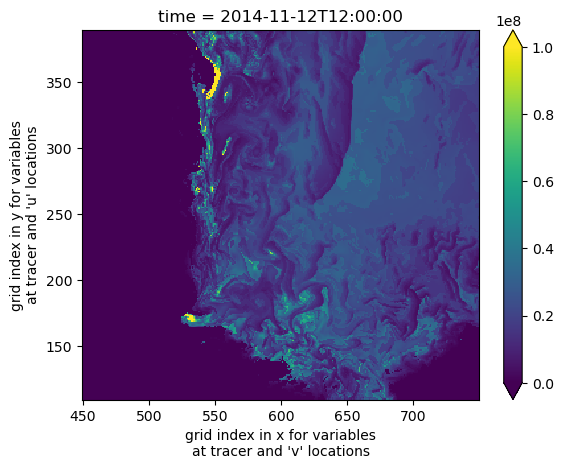

In [162]:
ohc_mld.isel(time=50).plot(vmin=0,vmax=1e8);

In [163]:
# name dataset and save dataset to zarr
mld.name = 'mld'
mld.to_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/MLD/MLD_KPP_Beaufort.ZARR')

mld_idx_da.name = 'mld_idx'
mld_idx_da.to_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/MLD/MLD_index_KPP_Beaufort.ZARR')

In [164]:
# name dataset and save dataset to zarr
ohc_mld.name = 'ohc'
ohc_mld.to_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/OHC/OHC_MLD_KPP_Beaufort.ZARR')

In [ ]:
def calculate_ohc_winterMLD(temp, salinity, density, layer_thickness, threshold_idx):
    """
    Calculate the Ocean Heat Content (OHC) relative to the freezing temperature in surface mixed layer for a time series of profiles.

    Args:
    - temp (xr.DataArray): 2D array of temperature (°C) with dimensions ['time', 'k'].
    - salinity (xr.DataArray): 2D array of salinity (PSU) with dimensions ['time', 'k'].
    - density (xr.DataArray): 2D array of seawater density (kg/m3) with dimensions ['time', 'k'].
    - layer_thickness (xr.DataArray): 1D array representing the thickness of each vertical layer (m).
    - threshold_idx (xr.DataArray): 1D array containing the maximum depth index for the MLD of each profile along the time series.

    Returns:
    - ohc (xr.DataArray): 3D array representing ocean heat content relative to the freezing temperature in the surface mixed layer for each profile (J/m2).
    """
    
    # specific heat capacity of seawater
    cp = calculate_cp_from_profile(salinity, temp, temp.Z, lon=temp.XC, lat=temp.YC)

    # Given array of indices
    # indices = threshold_idx.compute()

    # Create mask for depths between surface mixed layer and winter mixed layer (down to ~18m in this case)
    mask = (temp.k > threshold_idx) & (temp.k < 10)
    
    # Compute ocean heat content relative to freezing temperature per unit area
    temp_freezing = -1.8

    # Compute the weighted temperature anomaly and then OHC for the surface mixed layer
    weighted_temp_anomaly = (temp - temp_freezing) * layer_thickness
    weighted_temp_anomaly_layer = weighted_temp_anomaly.where(mask) # apply mask for specific depth layer
    ohc = (density * cp * weighted_temp_anomaly_layer).sum(dim='k')  # J/m^2

    # units check: (kg/m3)(J/(kg degC))(degC * m) = J/m2
    
    return ohc, mask

In [ ]:
HH_grid.isel(k_u=slice(0,10)).Zu.values # k=6 grid cell goes down to 18.6 m

In [ ]:
HH_grid.isel(k=slice(0,10)).Z.values # k=6 grid cell goes down to 18.6 m

In [ ]:
# calculate OHC between summer MLD and winter MLD
start = time.time()
ohc_mld_winter, mask_winter = calculate_ohc_winterMLD(temp_yrs, salt_yrs, rho_yrs, grid_beaufort.drF, mld_idx_da)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

In [ ]:
# sanity check to make sure mask is good
print(mask_winter.sel(j=260,i=560).isel(time=10).values)
print(mld_idx_da.sel(j=260,i=560).isel(time=10).values)

In [ ]:
# name dataset and save dataset to zarr
ohc_mld_winter.name = 'ohc_winter'
ohc_mld_winter.to_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/OHC/OHC_MLD_winter_Beaufort.ZARR')

In [ ]:
temp_yrs.sel(time='2019-09-30').isel(k=0).plot();

In [ ]:
def plot_profiles_and_mld(date, i, j, temp_yrs, salt_yrs, sigma0, grid_beaufort, threshold_idx_da, mld_da):
    # Create figure and axes
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=[6, 4], sharey=True, layout='constrained')

    # Plot temperature, salinity, and potential density
    temp_yrs.sel(i=i, j=j, time=date).plot(ax=ax1, y='Z', color='tab:blue', marker='.')
    salt_yrs.sel(i=i, j=j, time=date).plot(ax=ax2, y='Z', color='tab:red', marker='.')
    sigma0.sel(i=i, j=j, time=date).plot(ax=ax3, y='Z', color='k', marker='.')

    # Calculate MLD bottom and winter MLD
    mld_bottom = grid_beaufort.isel(k=int(threshold_idx_da.sel(i=i, j=j, time=date).values[0])).Z.values
    ax3.axhline(y=mld_bottom, color='tab:green', linestyle='dashed', label='Surface MLD')

    # Winter MLD bottom
    mld_winter_bottom = grid_beaufort.isel(k_u=9).Zu.values
    ax3.axhline(y=mld_winter_bottom, color='gray', linestyle='dashed', label='Winter MLD')
    ax3.legend()

    # Titles and labels
    ax1.set_title('Temperature')
    ax1.set_yticks(np.arange(0, -70, -10))
    ax1.set_yticklabels(np.arange(0, 70, 10))
    ax2.set_title('Salinity')
    ax3.set_title('Potential Density')

    ax1.set_ylim([-60, 2])

    # Additional formatting
    for ax in (ax1, ax2, ax3):
        ax.set_ylabel("")
        ax.grid(linewidth=0.2)

    ax1.set_ylabel('Depth (m)')
    plt.suptitle(f'Example profile on {date} at (i={i}, j={j})')

    plt.show()

In [ ]:
date='2017-10-15'
i=560
j=190
plot_profiles_and_mld(date, i, j, temp_yrs, salt_yrs, sigma0, grid_beaufort, threshold_idx_da, mld_da)

In [ ]:
ohc_mld_ds.ohc.sel(time='2019-10-01').plot();
plt.scatter(533,260,color='r')

#### Select grid cells above and below FCW of 2 m

In [9]:
# open FWC dataset
fwc_yrs_masked = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/FWC/FWC_masked_Beaufort.ZARR')
fwc_yrs_masked = fwc_yrs_masked.fwc_yrs_masked

In [12]:
# open OHC zarr stores
ohc_mld_ds = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/OHC/OHC_MLD_KPP_Beaufort.ZARR')
ohc_mld_win_ds = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/OHC/OHC_MLD_winter_Beaufort.ZARR')

In [13]:
# select all cells with FWC above and below 2
ohc_fwc_over_2m = ohc_mld_ds.ohc.where(fwc_yrs_masked>2).load()
ohc_fwc_under_2m = ohc_mld_ds.ohc.where(fwc_yrs_masked<2).load()

ohc_below_fwc_over_2m = ohc_mld_win_ds.ohc_winter.where(fwc_yrs_masked>2).load()
ohc_below_fwc_under_2m = ohc_mld_win_ds.ohc_winter.where(fwc_yrs_masked<2).load()

In [ ]:
# sanity check plots
fig, (ax1,ax2) = plt.subplots(1,2,sharex=True,sharey=True,figsize=[9,3])
ohc_fwc_over_2m.sel(time='2019-09-30').plot(ax=ax1,vmin=1e7,vmax=5e8,cmap='turbo');
ohc_fwc_under_2m.sel(time='2019-09-30').plot(ax=ax2,vmin=1e7,vmax=5e8,cmap='turbo');
ax1.set_title('FWC>2m')
ax2.set_title('FWC<2m')
ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("")
ax2.set_ylabel("");

In [ ]:
# sanity check plots
fig, (ax1,ax2) = plt.subplots(1,2,sharex=True,sharey=True,figsize=[9,3])
ohc_fwc_over_2m.sel(time='2019-10-30').plot(ax=ax1,vmin=1e7,vmax=8e8,cmap='turbo');
ohc_fwc_under_2m.sel(time='2019-10-30').plot(ax=ax2,vmin=1e7,vmax=8e8,cmap='turbo');
ax1.set_title('FWC>2m')
ax2.set_title('FWC<2m')
ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("")
ax2.set_ylabel("");

## Plot OHC in ML for FWC above and below 2 m

In [21]:
# look at SIC for the same FWC grouping
# select all cells with FWC above and below 2
ice_fwc_over_2m = sic_yrs.where(fwc_yrs_masked>2).load()
ice_fwc_under_2m = sic_yrs.where(fwc_yrs_masked<2).load()

### Add vertical lines for where SIC>=15% and remain above it for at least 5 days


In [ ]:
# first day when sea ice concentration (SIC) reaches or exceeds 15% and stays above that threshold for at least 5 consecutive days
years = np.arange(2014, 2021)

ice_fwc_over_2m_dates = []
ice_fwc_under_2m_dates = []

for year in years:
    # Compute mean SIC over space
    ice_over_mean = ice_fwc_over_2m.sel(time=str(year)).mean(dim=['i', 'j'], skipna=True).compute()
    ice_under_mean = ice_fwc_under_2m.sel(time=str(year)).mean(dim=['i', 'j'], skipna=True).compute()
    
    # Convert to boolean where SIC >= 15
    ice_over_bool = ice_over_mean >= 15
    ice_under_bool = ice_under_mean >= 15

    # Find the first day where there are 5+ consecutive True values
    def find_persistent_threshold(bool_array, time_array, window=5):
        bool_np = bool_array.values
        for i in range(len(bool_np) - window + 1):
            if np.all(bool_np[i:i+window]):
                return time_array[i].values
        return np.datetime64('NaT')  # If no valid period found

    over_time = ice_over_mean['time']
    under_time = ice_under_mean['time']

    ice_over_date = find_persistent_threshold(ice_over_bool, over_time)
    ice_under_date = find_persistent_threshold(ice_under_bool, under_time)

    ice_fwc_over_2m_dates.append(ice_over_date)
    ice_fwc_under_2m_dates.append(ice_under_date)

### Plot all years

In [ ]:
years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[10, 10], sharex=True, sharey=True)
plt.rcParams['font.size'] = 15
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_over = ohc_fwc_over_2m.sel(time=str(year))
    data_under = ohc_fwc_under_2m.sel(time=str(year))

    # Find first day when sea ice exists (mean_over is not NaN or > 0)
    mean_over = data_over.mean(dim=['i', 'j'])
    first_valid_index = mean_over.notnull().argmax().compute().item()
    
    # Extract the shifted data starting from sea ice onset
    mean_over = mean_over.isel(time=slice(first_valid_index, None))
    mean_under = data_under.mean(dim=['i', 'j']).isel(time=slice(first_valid_index, None))

    # Recalculate SE for the sliced data
    data_over_slice = data_over.isel(time=slice(first_valid_index, None))
    data_under_slice = data_under.isel(time=slice(first_valid_index, None))

    std_over = data_over_slice.std(dim=['i', 'j'])
    std_under = data_under_slice.std(dim=['i', 'j'])

    # Reset x-axis to be relative to the start of sea ice
    doy_shifted = np.arange(len(mean_over))

    # Plot
    ax.plot(doy_shifted, mean_over, color='tab:orange', label='FWC > 2m')
    ax.fill_between(doy_shifted, mean_over - std_over, mean_over + std_over, color='tab:orange', alpha=0.3)

    ax.plot(doy_shifted, mean_under, color='k', label='FWC < 2m')
    ax.fill_between(doy_shifted, mean_under - std_under, mean_under + std_under, color='gray', alpha=0.3)

    # add vertical lines for where SIC > 15%
    ax.axvline(x=np.where(data_over_slice.time.values == ice_fwc_over_2m_dates[i])[0][0], color='tab:orange', linestyle='dashed')
    ax.axvline(x=np.where(data_under_slice.time.values == ice_fwc_under_2m_dates[i])[0][0], color='k', linestyle='dashed')

    ax.set_title(f"{year}")
    ax.set_xlim([0, 80])
    ax.set_ylim([0, 10e8])
    ax.grid(True)

    if i == 5:
        ax.tick_params(labelbottom=True)        
    
# axes[6].set_xlabel("Days following sea ice minimum")

# Custom legend handles
custom_lines = [Line2D([0], [0], color='tab:orange', lw=2),\
                Line2D([0], [0], color='k', lw=2)]

# Only show legend in the bottom right subplot
if len(years) < len(axes):
    axes[-1].axis('off')

axes[-1].legend(
    custom_lines, ['FWC > 2m', 'FWC < 2m'],
    loc='lower left',
    fontsize=12,
    title_fontsize=13)

fig.supxlabel("Days following sea ice minimum", fontsize=15)
fig.supylabel("OHC relative to freezing temperature (J/m$^2$)", fontsize=15)
fig.suptitle("OHC in the surface mixed layer")

plt.tight_layout()
plt.show()

## Plot OHC in between surface and winter ML for FWC above and below 2 m

In [ ]:
years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[10, 10], sharex=True, sharey=True)
plt.rcParams['font.size'] = 15
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_over = ohc_below_fwc_over_2m.sel(time=str(year))
    data_under = ohc_below_fwc_under_2m.sel(time=str(year))

    # Find first day when sea ice exists (mean_over is not NaN or > 0)
    mean_over = data_over.mean(dim=['i', 'j'])
    first_valid_index = mean_over.notnull().argmax().compute().item()
    
    # Extract the shifted data starting from sea ice onset
    mean_over = mean_over.isel(time=slice(first_valid_index, None))
    mean_under = data_under.mean(dim=['i', 'j']).isel(time=slice(first_valid_index, None))

    # Recalculate SE for the sliced data
    data_over_slice = data_over.isel(time=slice(first_valid_index, None))
    data_under_slice = data_under.isel(time=slice(first_valid_index, None))

    std_over = data_over_slice.std(dim=['i', 'j'])
    std_under = data_under_slice.std(dim=['i', 'j'])

    # Reset x-axis to be relative to the start of sea ice
    doy_shifted = np.arange(len(mean_over))

    # Plot
    ax.plot(doy_shifted, mean_over, color='tab:orange', label='FWC > 2m')
    ax.fill_between(doy_shifted, mean_over - std_over, mean_over + std_over, color='tab:orange', alpha=0.3)

    ax.plot(doy_shifted, mean_under, color='k', label='FWC < 2m')
    ax.fill_between(doy_shifted, mean_under - std_under, mean_under + std_under, color='gray', alpha=0.3)

    # add vertical lines for where SIC > 15%
    ax.axvline(x=np.where(data_over_slice.time.values == ice_fwc_over_2m_dates[i])[0][0], color='tab:orange', linestyle='dashed')
    ax.axvline(x=np.where(data_under_slice.time.values == ice_fwc_under_2m_dates[i])[0][0], color='k', linestyle='dashed')

    ax.set_title(f"{year}")
    ax.set_xlim([0, 80])
    ax.set_ylim([0, 4e8])
    ax.grid(True)

    if i == 5:
        ax.tick_params(labelbottom=True)        
    
# axes[6].set_xlabel("Days following sea ice minimum")

# Custom legend handles
custom_lines = [Line2D([0], [0], color='tab:orange', lw=2),\
                Line2D([0], [0], color='k', lw=2)]

# Only show legend in the bottom right subplot
if len(years) < len(axes):
    axes[-1].axis('off')

axes[-1].legend(
    custom_lines, ['FWC > 2m', 'FWC < 2m'],
    loc='lower left',
    fontsize=12,
    title_fontsize=13)

fig.supxlabel("Days following sea ice minimum", fontsize=15)
fig.supylabel("OHC relative to freezing temperature (J/m$^2$)", fontsize=15)
fig.suptitle("OHC in layer between surface and winter MLD")

plt.tight_layout()
plt.show()

## Plot MLD

In [24]:
mld_da = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/MLD/MLD_KPP_Beaufort.ZARR')

In [180]:
# select all cells with FWC above and below 2
mld_fwc_over_2m = (mld_da.mld.where(fwc_yrs_masked.fwc_yrs_masked>2)*-1).load()
mld_fwc_under_2m = (mld_da.mld.where(fwc_yrs_masked.fwc_yrs_masked<2)*-1).load()

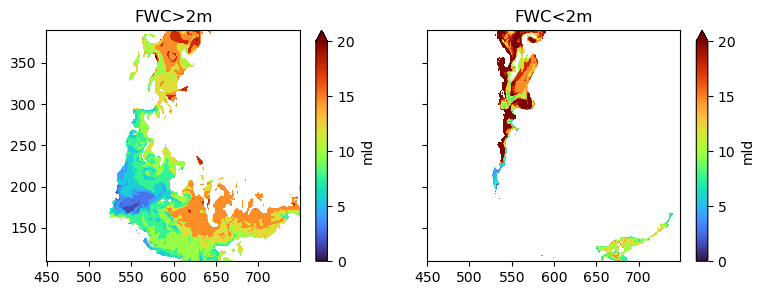

In [181]:
# sanity check plots
fig, (ax1,ax2) = plt.subplots(1,2,sharex=True,sharey=True,figsize=[9,3])
mld_fwc_over_2m.sel(time='2019-09-30').isel(time=0).plot(ax=ax1,vmin=0,vmax=20,cmap='turbo');
mld_fwc_under_2m.sel(time='2019-09-30').isel(time=0).plot(ax=ax2,vmin=0,vmax=20,cmap='turbo');
ax1.set_title('FWC>2m')
ax2.set_title('FWC<2m')
ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("")
ax2.set_ylabel("");

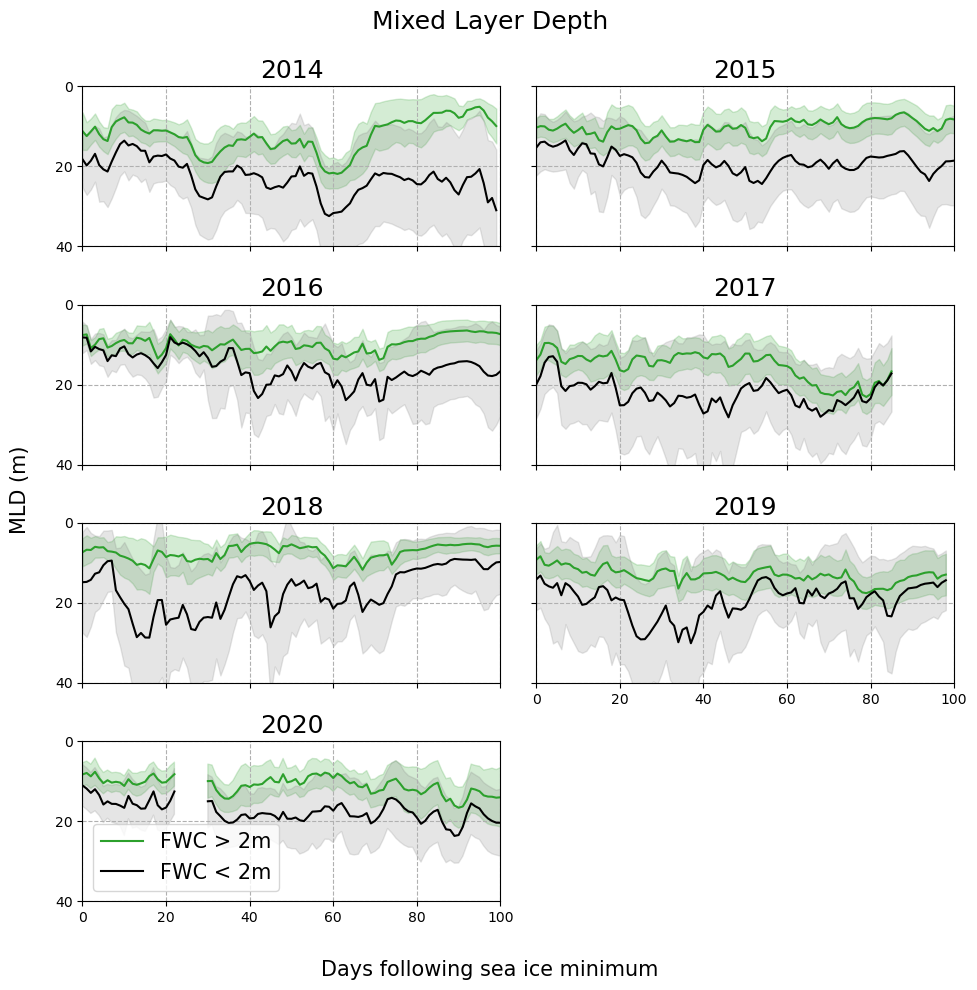

In [182]:
years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[10, 10], sharex=True, sharey=True)
plt.rcParams['font.size'] = 15
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_over = mld_fwc_over_2m.sel(time=str(year))
    data_under = mld_fwc_under_2m.sel(time=str(year))

    # Find first day when sea ice exists (mean_over is not NaN or > 0)
    mean_over = data_over.mean(dim=['i', 'j'])
    first_valid_index = mean_over.notnull().argmax().compute().item()
    
    # Extract the shifted data starting from sea ice onset
    mean_over = mean_over.isel(time=slice(first_valid_index, None))
    mean_under = data_under.mean(dim=['i', 'j']).isel(time=slice(first_valid_index, None))

    # Recalculate SE for the sliced data
    data_over_slice = data_over.isel(time=slice(first_valid_index, None))
    data_under_slice = data_under.isel(time=slice(first_valid_index, None))

    std_over = data_over_slice.std(dim=['i', 'j'])
    std_under = data_under_slice.std(dim=['i', 'j'])

    # Reset x-axis to be relative to the start of sea ice
    doy_shifted = np.arange(len(mean_over))

    # Plot
    ax.plot(doy_shifted, mean_over, color='tab:green', label='FWC > 2m')
    ax.fill_between(doy_shifted, mean_over - std_over, mean_over + std_over, color='tab:green', alpha=0.2)

    ax.plot(doy_shifted, mean_under, color='k', label='FWC < 2m')
    ax.fill_between(doy_shifted, mean_under - std_under, mean_under + std_under, color='gray', alpha=0.2)

    ax.set_title(f"{year}")
    ax.set_xlim([0, 100])
    ax.set_ylim([40, 0])
    # ax.set_yticks([2, 4, 6, 8, 10])
    ax.grid(True,linestyle='dashed')

    if i == 5:
        ax.tick_params(labelbottom=True)        
    
# axes[6].set_xlabel("Days following sea ice minimum")

# Turn off the last axis if unused (e.g., 8th subplot)
if len(years) < len(axes):
    axes[-1].axis('off')

# Add legend to the first axis
axes[-2].legend(loc='lower left')

fig.supxlabel("Days following sea ice minimum", fontsize=15)
fig.supylabel("MLD (m)", fontsize=15)
fig.suptitle("Mixed Layer Depth")

plt.tight_layout()
plt.show()

In [183]:
from matplotlib.lines import Line2D

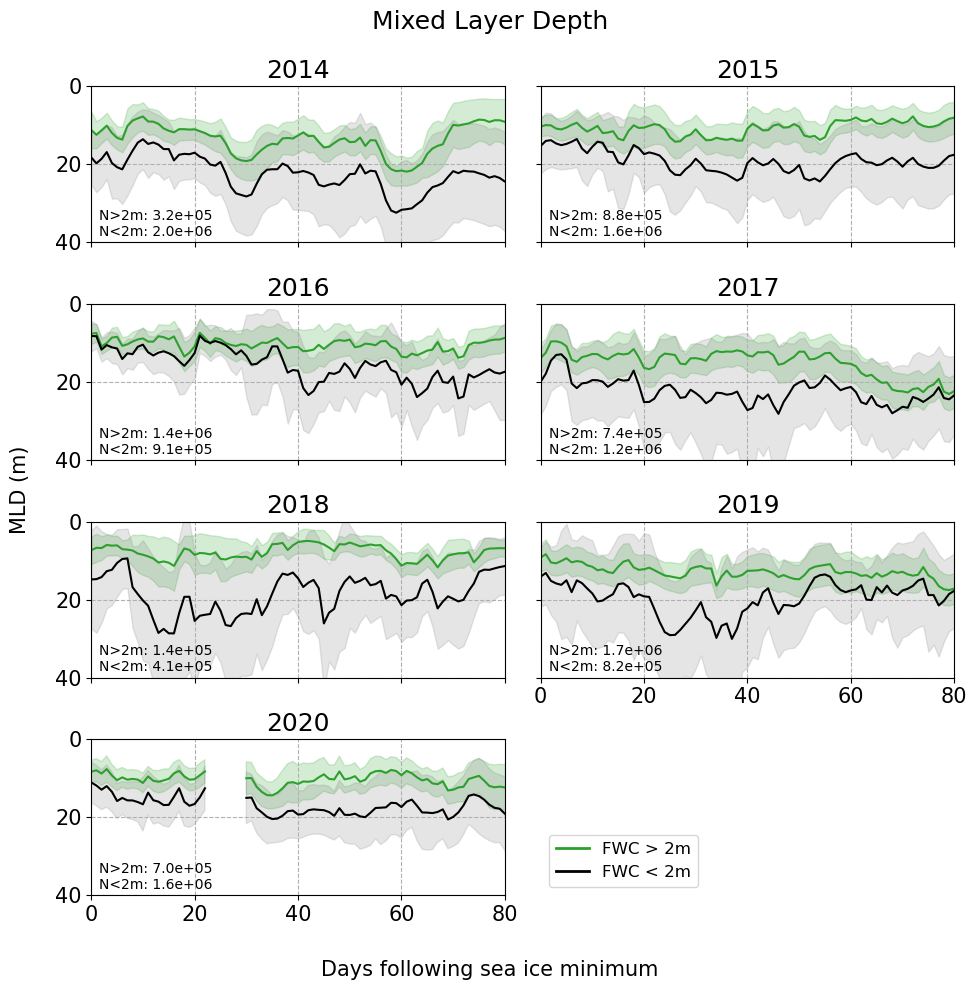

In [184]:
years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[10, 10], sharex=True, sharey=True)
plt.rcParams['font.size'] = 15
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_over = mld_fwc_over_2m.sel(time=str(year))
    data_under = mld_fwc_under_2m.sel(time=str(year))

    # Find first day when sea ice exists (mean_over is not NaN or > 0)
    mean_over = data_over.mean(dim=['i', 'j'])
    first_valid_index = mean_over.notnull().argmax().compute().item()
    
    # Extract the shifted data starting from sea ice onset
    mean_over = mean_over.isel(time=slice(first_valid_index, None))
    mean_under = data_under.mean(dim=['i', 'j']).isel(time=slice(first_valid_index, None))

    # Recalculate SE for the sliced data
    data_over_slice = data_over.isel(time=slice(first_valid_index, None))
    data_under_slice = data_under.isel(time=slice(first_valid_index, None))

    std_over = data_over_slice.std(dim=['i', 'j'])
    std_under = data_under_slice.std(dim=['i', 'j'])

    # Calculate total number of valid (non-NaN) observations for each group
    n_over = np.count_nonzero(~np.isnan(data_over_slice.values))
    n_under = np.count_nonzero(~np.isnan(data_under_slice.values))

    # Reset x-axis to be relative to the start of sea ice
    doy_shifted = np.arange(len(mean_over))

    # Plot
    ax.plot(doy_shifted, mean_over, color='tab:green', label='FWC > 2m')
    ax.fill_between(doy_shifted, mean_over - std_over, mean_over + std_over, color='tab:green', alpha=0.2)

    ax.plot(doy_shifted, mean_under, color='k', label='FWC < 2m')
    ax.fill_between(doy_shifted, mean_under - std_under, mean_under + std_under, color='gray', alpha=0.2)

    ax.set_title(f"{year}")
    ax.set_xlim([0, 80])
    ax.set_ylim([40, 0])
    ax.grid(True, linestyle='dashed')

    # # Add sample size text in bottom left
    # ax.text(0.02, 0.02, f"N>2m: {n_over}\nN<2m: {n_under}", 
    #         transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left')

    # Add sample size text in scientific notation in bottom left
    ax.text(
        0.02, 0.02,
        f"N>2m: {n_over:.1e}\nN<2m: {n_under:.1e}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='bottom',
        horizontalalignment='left'
    )

    if i == 5:
        ax.tick_params(labelbottom=True)        

# Custom legend handles
custom_lines = [Line2D([0], [0], color='tab:green', lw=2),\
                Line2D([0], [0], color='k', lw=2)]

# Only show legend in the bottom right subplot
if len(years) < len(axes):
    axes[-1].axis('off')

axes[-1].legend(
    custom_lines, ['FWC > 2m', 'FWC < 2m'],
    loc='lower left',
    fontsize=12,
    title_fontsize=13)

fig.supxlabel("Days following sea ice minimum", fontsize=15)
fig.supylabel("MLD (m)", fontsize=15)
fig.suptitle("Mixed Layer Depth")

plt.tight_layout()
plt.show()

### Plot 95% CI for shading

In [ ]:
from scipy.stats import sem

years = np.arange(2014, 2021)
nrows = int(np.ceil(len(years) / 2))

fig, axes = plt.subplots(nrows, 2, figsize=[10, 10], sharex=True, sharey=True)
plt.rcParams['font.size'] = 15
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]

    # Select data for the given year
    data_over = mld_fwc_over_2m.sel(time=str(year))
    data_under = mld_fwc_under_2m.sel(time=str(year))

    # Find first day when sea ice exists (mean_over is not NaN or > 0)
    mean_over = data_over.mean(dim=['i', 'j'])
    first_valid_index = mean_over.notnull().argmax().compute().item()
    
    # Extract the shifted data starting from sea ice onset
    mean_over = mean_over.isel(time=slice(first_valid_index, None))
    mean_under = data_under.mean(dim=['i', 'j']).isel(time=slice(first_valid_index, None))

    # Extract data slice to compute SEM
    data_over_slice = data_over.isel(time=slice(first_valid_index, None))
    data_under_slice = data_under.isel(time=slice(first_valid_index, None))

    # Compute SEM (standard error of the mean)
    n_over = data_over_slice.count(dim=['i', 'j'])  # count non-NaNs per timestep
    n_under = data_under_slice.count(dim=['i', 'j'])

    std_over = data_over_slice.std(dim=['i', 'j'])
    std_under = data_under_slice.std(dim=['i', 'j'])

    sem_over = std_over / np.sqrt(n_over)
    sem_under = std_under / np.sqrt(n_under)

    # Compute 95% confidence intervals
    ci95_over = 1.96 * sem_over
    ci95_under = 1.96 * sem_under

    # Reset x-axis to be relative to the start of sea ice
    doy_shifted = np.arange(len(mean_over))

    # Plot means and 95% CI shading
    ax.plot(doy_shifted, mean_over, color='tab:green', label='FWC > 2m')
    ax.fill_between(doy_shifted, mean_over - ci95_over, mean_over + ci95_over, color='tab:green', alpha=0.2)

    ax.plot(doy_shifted, mean_under, color='k', label='FWC < 2m')
    ax.fill_between(doy_shifted, mean_under - ci95_under, mean_under + ci95_under, color='gray', alpha=0.2)

    ax.set_title(f"{year}")
    ax.set_xlim([0, 100])
    ax.set_ylim([40, 0])
    ax.grid(True, linestyle='dashed')

    if i == 5:
        ax.tick_params(labelbottom=True)

# Turn off the last axis if unused
if len(years) < len(axes):
    axes[-1].axis('off')

# Add legend to the first axis
axes[-2].legend(loc='lower left')

fig.supxlabel("Days following sea ice minimum", fontsize=15)
fig.supylabel("MLD (m)", fontsize=15)
fig.suptitle("Mixed Layer Depth")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import ttest_ind

years = np.arange(2014, 2021)
pvals_by_year = {}

for year in years:
    # Select data for the year
    data_over = mld_fwc_over_2m.sel(time=str(year))
    data_under = mld_fwc_under_2m.sel(time=str(year))

    # Use mean to find first valid sea ice day
    mean_over = data_over.mean(dim=['i', 'j'])
    first_valid_index = mean_over.notnull().argmax().compute().item()

    # Slice data from sea ice onset onward
    over_slice = data_over.isel(time=slice(first_valid_index, None))
    under_slice = data_under.isel(time=slice(first_valid_index, None))

    pvals = []

    for t in range(over_slice.sizes['time']):
        g1 = over_slice.isel(time=t).values.flatten()
        g2 = under_slice.isel(time=t).values.flatten()
        g1 = g1[~np.isnan(g1)]
        g2 = g2[~np.isnan(g2)]

        if len(g1) > 5 and len(g2) > 5:
            _, p = ttest_ind(g1, g2, equal_var=False)
        else:
            p = np.nan

        pvals.append(p)

    pvals_by_year[year] = np.array(pvals)

In [ ]:
print(pvals_by_year[2016])

In [ ]:
# Flatten across all dimensions: time, i, j
over_flat = mld_fwc_over_2m.values.flatten()
under_flat = mld_fwc_under_2m.values.flatten()

# Remove NaNs
over_clean = over_flat[~np.isnan(over_flat)]
under_clean = under_flat[~np.isnan(under_flat)]

In [ ]:
tstat, pval_ttest = ttest_ind(over_clean, under_clean, equal_var=False)

print(f"Welch's t-test:")
print(f"  t-statistic = {tstat:.4f}")
print(f"  p-value     = {pval_ttest:.4e}")

In [ ]:
from scipy.stats import ks_2samp

ks_stat, pval_ks = ks_2samp(over_clean, under_clean)

print(f"Kolmogorov–Smirnov test:")
print(f"  KS statistic = {ks_stat:.4f}")
print(f"  p-value      = {pval_ks:.4e}")